Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data: 590
Rows with an existing high-bias image: 584

Reusing fold assignments from cv5_convnext_base_highbias_j0_fold_assignments.csv
Modules listed in fold file: 389

Fold source: reused_from_hybrid_fold_csv
Modules used: 389
Block sizes: [78, 78, 78, 78, 77]
  Fold 1: train=233, val=78, test=78, seed=82
  Fold 2: train=233, val=78, test=78, seed=83
  Fold 3: train=233, val=78, test=78, seed=84
  Fold 4: train=234, val=77, test=78, seed=85
  Fold 5: train=234, val=78, test=77, seed=86

Preloading 389 high-bias images into RAM (once, all folds)...
Expected memory: ~19 MB
Done in 139.7s | RAM used: 18.6 MB | Failed: 0

FOLD 1/5 | ConvNeXt-Base high-bias only | seed = 82
test block = 0 (78) | val block = 1 (78) | train (233)
  Backbone parameters: 87,560,320
  Head parameters:     3,073
  Total parameters:    87,563,393
  Epoch 

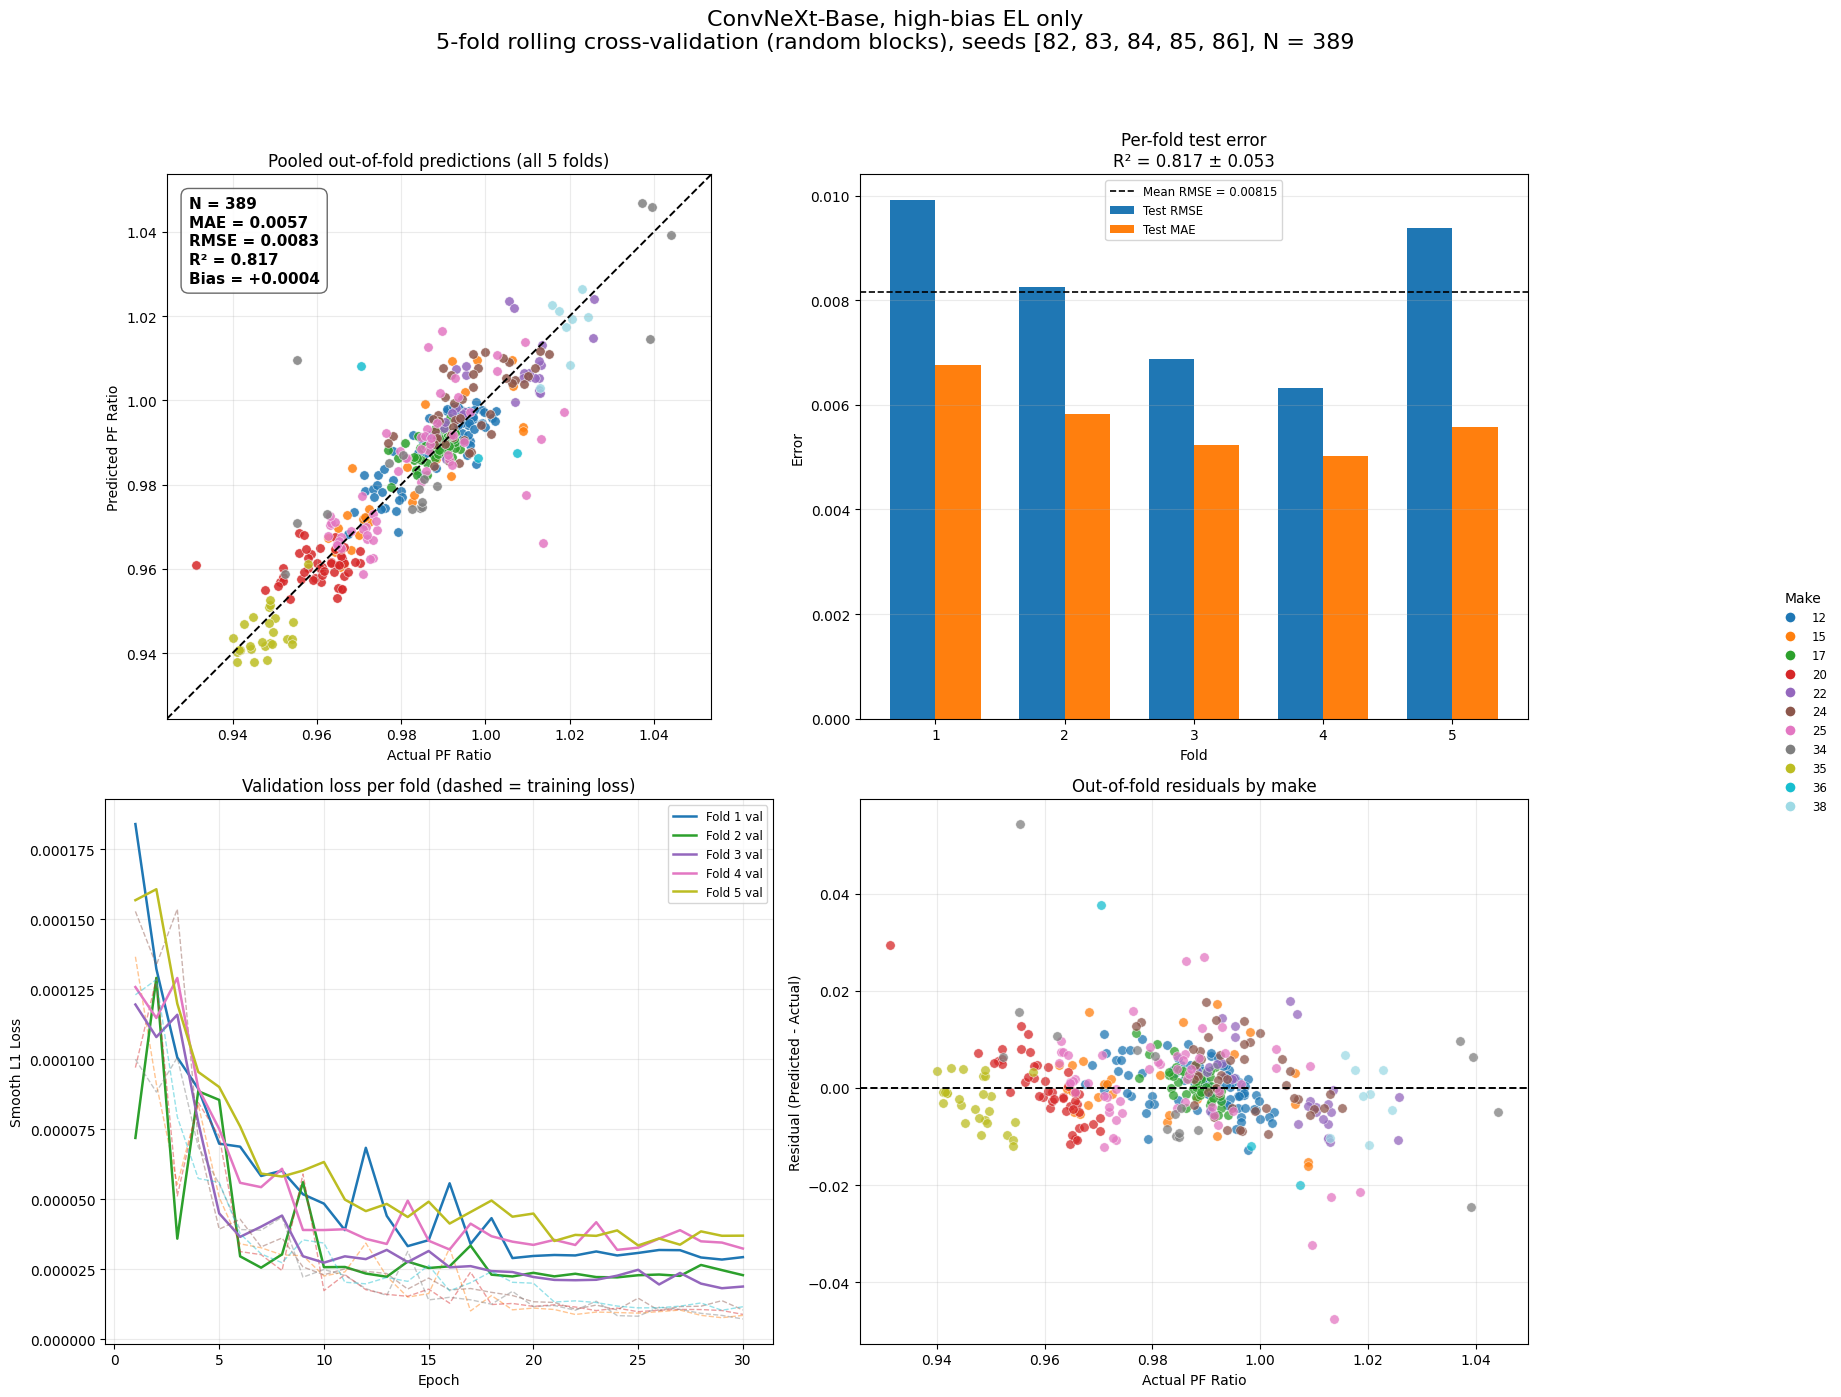


Saved:
- cv5_convnext_base_highbias_only_seedC_fold_assignments.csv
- cv5_convnext_base_highbias_only_seedC_config.json
- cv5_convnext_base_highbias_only_seedC_cv_summary.png
- cv5_convnext_base_highbias_only_seedC_per_fold_metrics.csv
- cv5_convnext_base_highbias_only_seedC_summary_metrics.csv
- cv5_convnext_base_highbias_only_seedC_oof_test_predictions.csv
- cv5_convnext_base_highbias_only_seedC_all_validation_predictions.csv
- cv5_convnext_base_highbias_only_seedC_training_history.csv
- cv5_convnext_base_highbias_only_seedC_oof_metrics_per_make.csv
- cv5_convnext_base_highbias_only_seedC_fold1..5_best_val_model.pth
Cleanup done.


In [1]:
"""
5-fold rolling cross-validation
ConvNeXt-Base, 1-channel input: high-bias EL image only

This is the matched control for cv5_convnext_base_highbias_j0.py. It uses
EXACTLY the same modules and exactly the same fold membership, so the only
difference between the two experiments is the input representation.

How the sample set is matched
-----------------------------
Primary path (preferred):
    Read FOLD_CSV_PATH, the fold assignment file written by the hybrid run,
    and inner-join on sample_uid. Fold membership and per-fold training seeds
    are taken verbatim from that file. Expected: 389 modules, block sizes
    [78, 78, 78, 78, 77].

Fallback path (if FOLD_CSV_PATH is missing):
    Rebuild the identical partition from scratch. The same J0-map existence
    filter is applied, and the same FOLD_ASSIGNMENT_SEED and rolling rule are
    used, so the reconstructed blocks match the hybrid run module-for-module.
    A warning is printed when this path is taken.

The J0 maps are never read as model input here. They are only consulted, in
the fallback path, to reproduce the eligible sample population.
"""

import os
import math
import copy
import random
import time
import gc
import json

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"

# Fold assignment file written by the hybrid (high-bias + J0) run.
FOLD_CSV_PATH = "cv5_convnext_base_highbias_j0_fold_assignments.csv"

# Only used by the fallback path, to reproduce the eligible sample population.
PHYSICS_MAP_DIR = "J0_Rs"
REQUIRE_J0_MAP = True

IMAGE_SIZE = 224
BATCH_SIZE = 2  # ConvNeXt-Base on a 4 GB RTX 3050; use 1 if CUDA runs out of memory
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
NUM_WORKERS = 0

# Keep False to match the numerics of the existing single-split runs.
USE_AMP = False

N_FOLDS = 5
FOLD_ASSIGNMENT_SEED = 42
TRAINING_SEEDS = [82, 83, 84, 85, 86]      # was [42, 43, 44, 45, 46]

# Must match the hybrid run. None = random blocks, "Make" = group-aware blocks.
GROUP_COLUMN = None

OUTPUT_PREFIX = "cv5_convnext_base_highbias_only_seedC"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


# =========================================================
# PATH HELPERS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_j0_path(elh_path_str, base_dir):
    """Only used by the fallback path to reproduce the eligible population."""
    if pd.isna(elh_path_str):
        return None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)
    base_name = name.rsplit("_", 1)[0]

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )
    io_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )

    if not os.path.exists(j0_path) and os.path.exists(io_fallback):
        j0_path = io_fallback

    return j0_path


def derive_sample_uid(elh_path_str):
    """Join key shared with the hybrid run's fold assignment CSV."""
    if pd.isna(elh_path_str):
        return None

    filename = os.path.basename(str(elh_path_str).strip())
    name, _ = os.path.splitext(filename)
    return name.rsplit("_", 1)[0]


# =========================================================
# DATAFRAME PREPARATION
# =========================================================
def prepare_dataframe(csv_path):
    """
    Build the candidate table. No J0 filtering happens here: the sample set is
    fixed later, either by the fold CSV or by the fallback reconstruction.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)", MAKE_COLUMN]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]
    df["sample_uid"] = df["ELHPath"].apply(derive_sample_uid)

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir, add_wrp=True)
    )
    df["j0_path"] = df["ELHPath"].apply(lambda p: derive_j0_path(p, base_dir))

    df = df[df["high_path"].notna()].copy()
    df["high_exists"] = df["high_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(lambda p: bool(p) and os.path.exists(p))

    total_before = len(df)
    df = df[df["high_exists"]].copy()

    print(f"Rows with valid power data: {total_before}")
    print(f"Rows with an existing high-bias image: {len(df)}")

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        "sample_uid",
        "ELHPath",
        MAKE_COLUMN,
        "make_plot",
        "high_path",
        "j0_exists",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# FOLD CONSTRUCTION
# =========================================================
def build_rolling_blocks(df, n_folds, fold_seed, group_column=None):
    """Identical logic to the hybrid script, so blocks reproduce exactly."""
    n = len(df)
    rng = np.random.default_rng(fold_seed)
    block_of_row = np.full(n, -1, dtype=int)

    if group_column is None:
        order = rng.permutation(n)
        for b, idx in enumerate(np.array_split(order, n_folds)):
            block_of_row[idx] = b
        return block_of_row

    if group_column not in df.columns:
        raise ValueError(f"GROUP_COLUMN '{group_column}' not present in dataframe.")

    groups = df[group_column].fillna("Unknown").astype(str).to_numpy()
    uniq, counts = np.unique(groups, return_counts=True)

    perm = rng.permutation(len(uniq))
    uniq, counts = uniq[perm], counts[perm]
    order = np.argsort(-counts, kind="stable")

    load = np.zeros(n_folds, dtype=int)
    group_to_block = {}

    for gi in order:
        b = int(np.argmin(load))
        group_to_block[uniq[gi]] = b
        load[b] += int(counts[gi])

    for i in range(n):
        block_of_row[i] = group_to_block[groups[i]]

    print("\nGroup-aware block sizes:", load.tolist())
    return block_of_row


def fold_indices(block_of_row, fold_index, n_folds):
    """fold_index is 0-based. test = block k, val = block k+1, train = rest."""
    test_block = fold_index
    val_block = (fold_index + 1) % n_folds

    test_idx = np.where(block_of_row == test_block)[0]
    val_idx = np.where(block_of_row == val_block)[0]
    train_idx = np.where(
        (block_of_row != test_block) & (block_of_row != val_block)
    )[0]

    return train_idx, val_idx, test_idx


def load_or_rebuild_folds(df):
    """
    Returns (df_matched, block_of_row, source_string).

    df_matched is restricted and reordered to the hybrid run's sample set.
    """
    if os.path.exists(FOLD_CSV_PATH):
        folds = pd.read_csv(FOLD_CSV_PATH)

        if "sample_uid" not in folds.columns or "block" not in folds.columns:
            raise ValueError(
                f"{FOLD_CSV_PATH} does not contain sample_uid and block columns."
            )

        print(f"\nReusing fold assignments from {FOLD_CSV_PATH}")
        print(f"Modules listed in fold file: {len(folds)}")

        merged = folds[["sample_uid", "block"]].merge(
            df, on="sample_uid", how="left", validate="one_to_one"
        )

        missing = merged["high_path"].isna()

        if missing.any():
            print(
                f"\nWARNING: {int(missing.sum())} module(s) from the fold file "
                "have no usable high-bias image here and will be dropped:"
            )
            for uid in merged.loc[missing, "sample_uid"].head(20):
                print(f"  - {uid}")
            merged = merged[~missing].copy()

        merged = merged.reset_index(drop=True)
        block_of_row = merged["block"].to_numpy(dtype=int)
        merged = merged.drop(columns=["block"])

        return merged, block_of_row, "reused_from_hybrid_fold_csv"

    # ---- Fallback ----
    print(f"\nWARNING: {FOLD_CSV_PATH} not found.")
    print("Rebuilding the identical partition from scratch instead.")
    print("The J0-map existence filter is reapplied so the module set matches.")

    if REQUIRE_J0_MAP:
        before = len(df)
        df = df[df["j0_exists"]].copy().reset_index(drop=True)
        print(f"Modules with a J0 map: {len(df)} (dropped {before - len(df)})")

    block_of_row = build_rolling_blocks(
        df, N_FOLDS, FOLD_ASSIGNMENT_SEED, GROUP_COLUMN
    )

    return df, block_of_row, "rebuilt_from_seed"


def build_fold_assignment_table(df, block_of_row, n_folds):
    table = df[["sample_uid", "ELHPath", MAKE_COLUMN, "pf_ratio"]].copy()
    table["block"] = block_of_row

    for k in range(n_folds):
        train_idx, val_idx, test_idx = fold_indices(block_of_row, k, n_folds)

        col = np.empty(len(df), dtype=object)
        col[train_idx] = "train"
        col[val_idx] = "val"
        col[test_idx] = "test"

        table[f"fold_{k + 1}_split"] = col
        table[f"fold_{k + 1}_seed"] = TRAINING_SEEDS[k]

    return table


# =========================================================
# IMAGE PROCESSING
# =========================================================
def read_grayscale_tiff(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    return img


def resize_with_padding_gray(img, target_size=224):
    """Preserve aspect ratio and pad to a square input."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)
    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


# =========================================================
# MASTER RAM CACHE (loaded once, shared by all folds)
# =========================================================
class MasterCache:
    def __init__(self, dataframe, image_size=224):
        self.image_size = image_size
        n = len(dataframe)

        expected_mb = n * image_size * image_size / (1024 ** 2)

        print(f"\nPreloading {n} high-bias images into RAM (once, all folds)...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.high = np.empty((n, image_size, image_size), dtype=np.uint8)
        self.pf = dataframe["pf_ratio"].to_numpy(dtype=np.float32)

        failed = 0

        for i in range(n):
            row = dataframe.iloc[i]
            try:
                self.high[i] = resize_with_padding_gray(
                    read_grayscale_tiff(row["high_path"]), image_size
                )
            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.high[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = self.high.nbytes / (1024 ** 2)

        print(f"Done in {elapsed:.1f}s | RAM used: {mem_mb:.1f} MB | Failed: {failed}")


class FoldSubsetDataset(Dataset):
    """Views into the master cache. No file I/O between folds."""

    def __init__(self, master, indices, augment=False):
        self.master = master
        self.indices = np.asarray(indices, dtype=int)
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def apply_augmentation(self, high_img):
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)

        return high_img

    def __getitem__(self, i):
        idx = self.indices[i]

        high_img = self.master.high[idx].copy()

        if self.augment:
            high_img = self.apply_augmentation(high_img)

        high_img = high_img.astype(np.float32) / 255.0

        # [H, W] -> [1, H, W]
        x = np.expand_dims(high_img, axis=0)
        y = float(self.master.pf[idx])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL: ConvNeXt-Base, 1-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_1ch(pretrained=True):
    """ConvNeXt-Base modified for one-channel high-bias grayscale EL input."""
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem: features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        dilation=old_conv.dilation,
        groups=old_conv.groups,
        bias=(old_conv.bias is not None),
        padding_mode=old_conv.padding_mode,
    )

    with torch.no_grad():
        if pretrained:
            # Grayscale channel initialised from the mean RGB filter.
            new_conv.weight[:, 0, :, :] = old_conv.weight.mean(dim=1)

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )
            if new_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier: LayerNorm2d + Flatten + Linear
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(in_features, min_val=0.80, max_val=1.20)

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device, use_amp=False):
    model.eval()

    running_loss = 0.0
    preds, trues = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            if use_amp:
                with torch.autocast(device_type=device.type, dtype=torch.float16):
                    outputs = model(inputs)
                outputs = outputs.float()
            else:
                outputs = model(inputs)

            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# ONE FOLD
# =========================================================
def run_one_fold(fold_index, df, master, block_of_row):
    fold_number = fold_index + 1
    seed = TRAINING_SEEDS[fold_index]

    train_idx, val_idx, test_idx = fold_indices(block_of_row, fold_index, N_FOLDS)

    print(f"\n{'=' * 78}")
    print(
        f"FOLD {fold_number}/{N_FOLDS} | ConvNeXt-Base high-bias only | seed = {seed}"
    )
    print(
        f"test block = {fold_index} ({len(test_idx)}) | "
        f"val block = {(fold_index + 1) % N_FOLDS} ({len(val_idx)}) | "
        f"train ({len(train_idx)})"
    )
    print(f"{'=' * 78}")

    if min(len(train_idx), len(val_idx), len(test_idx)) == 0:
        raise ValueError(f"Fold {fold_number} has an empty split.")

    set_seed(seed)

    train_dataset = FoldSubsetDataset(master, train_idx, augment=True)
    val_dataset = FoldSubsetDataset(master, val_idx, augment=False)
    test_dataset = FoldSubsetDataset(master, test_idx, augment=False)

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )

    model = build_convnext_base_1ch(pretrained=True).to(DEVICE)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    if fold_number == 1:
        print(f"  Backbone parameters: {sum(p.numel() for p in backbone_params):,}")
        print(f"  Head parameters:     {sum(p.numel() for p in head_params):,}")
        print(f"  Total parameters:    {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    use_amp = USE_AMP and DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda") if use_amp else None

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    history = []
    t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler)

        train_eval_loss, _, _, _, _, _ = evaluate(
            model, train_loader, criterion, DEVICE, use_amp
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE, use_amp
        )
        test_loss, _, _, _, _, _ = evaluate(
            model, test_loader, criterion, DEVICE, use_amp
        )

        scheduler.step(val_loss)

        history.append(
            {
                "fold": fold_number,
                "seed": seed,
                "epoch": epoch + 1,
                "train_loss": train_eval_loss,
                "validation_loss": val_loss,
                "test_loss": test_loss,
                "backbone_lr": current_backbone_lr,
                "head_lr": current_head_lr,
            }
        )

        print(
            f"  Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{time.time() - epoch_t0:.1f}s | "
            f"Train {train_eval_loss:.6f} | "
            f"Val {val_loss:.6f} | "
            f"Test {test_loss:.6f} | "
            f"Val MAE {val_mae:.6f} | "
            f"Val RMSE {val_rmse:.6f} | "
            f"Val R2 {val_r2:.4f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    fold_seconds = time.time() - t0
    print(
        f"  Fold time: {fold_seconds:.1f}s ({fold_seconds / 60:.1f} min) | "
        f"best epoch: {best_epoch}"
    )

    model.load_state_dict(best_model_wts)

    _, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE, use_amp
    )
    _, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE, use_amp
    )

    print(
        f"  VAL  MAE {val_mae:.6f} | RMSE {val_rmse:.6f} | R2 {val_r2:.6f}\n"
        f"  TEST MAE {test_mae:.6f} | RMSE {test_rmse:.6f} | R2 {test_r2:.6f}"
    )

    history_df = pd.DataFrame(history)
    history_df["is_best_epoch"] = history_df["epoch"] == best_epoch

    def prediction_table(indices, trues, preds, split_name):
        table = df.iloc[indices].reset_index(drop=True).copy()
        table["fold"] = fold_number
        table["seed"] = seed
        table["evaluation_split"] = split_name
        table["actual_pf_ratio"] = trues
        table["predicted_pf_ratio"] = preds
        table["residual"] = preds - trues
        table["absolute_error"] = np.abs(preds - trues)
        return table

    test_table = prediction_table(test_idx, test_trues, test_preds, "test")
    val_table = prediction_table(val_idx, val_trues, val_preds, "validation")

    model_path = f"{OUTPUT_PREFIX}_fold{fold_number}_best_val_model.pth"
    torch.save(model.state_dict(), model_path)

    del model, optimizer, train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    fold_metrics = {
        "fold": fold_number,
        "seed": seed,
        "best_epoch": best_epoch,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_test": len(test_idx),
        "val_MAE": val_mae,
        "val_RMSE": val_rmse,
        "val_R2": val_r2,
        "test_MAE": test_mae,
        "test_RMSE": test_rmse,
        "test_R2": test_r2,
        "model_path": model_path,
    }

    return fold_metrics, history_df, test_table, val_table


# =========================================================
# PLOTTING
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]
    return dict(zip(makes, colours))


def plot_oof_scatter(ax, oof_df, make_palette):
    values = np.concatenate(
        [oof_df["actual_pf_ratio"].to_numpy(), oof_df["predicted_pf_ratio"].to_numpy()]
    )
    minimum, maximum = float(values.min()), float(values.max())
    margin = max((maximum - minimum) * 0.06, 0.003)
    minimum, maximum = minimum - margin, maximum + margin

    for make_value, group in oof_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=46,
            color=make_palette[make_value],
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
            label=make_value,
        )

    ax.plot([minimum, maximum], [minimum, maximum], "--", color="black", linewidth=1.4)
    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title("Pooled out-of-fold predictions (all 5 folds)")
    ax.grid(True, alpha=0.25)

    actual = oof_df["actual_pf_ratio"].to_numpy()
    predicted = oof_df["predicted_pf_ratio"].to_numpy()

    text = (
        f"N = {len(actual)}\n"
        f"MAE = {mean_absolute_error(actual, predicted):.4f}\n"
        f"RMSE = {math.sqrt(mean_squared_error(actual, predicted)):.4f}\n"
        f"R² = {r2_score(actual, predicted):.3f}\n"
        f"Bias = {np.mean(predicted - actual):+.4f}"
    )

    ax.text(
        0.04, 0.96, text, transform=ax.transAxes, ha="left", va="top",
        fontsize=11, fontweight="bold", linespacing=1.3,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.35", alpha=0.9),
    )


def plot_fold_metric_bars(ax, metrics_df):
    folds = metrics_df["fold"].to_numpy()
    width = 0.35

    ax.bar(folds - width / 2, metrics_df["test_RMSE"], width, label="Test RMSE")
    ax.bar(folds + width / 2, metrics_df["test_MAE"], width, label="Test MAE")

    ax.axhline(
        metrics_df["test_RMSE"].mean(), linestyle="--", color="black", linewidth=1.2,
        label=f"Mean RMSE = {metrics_df['test_RMSE'].mean():.5f}",
    )

    ax.set_xticks(folds)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Error")
    ax.set_title(
        "Per-fold test error\n"
        f"R² = {metrics_df['test_R2'].mean():.3f} ± {metrics_df['test_R2'].std(ddof=1):.3f}"
    )
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend(fontsize=8.5)


def plot_all_fold_losses(ax, history_df):
    for fold_number, group in history_df.groupby("fold"):
        ax.plot(
            group["epoch"], group["validation_loss"],
            linewidth=1.8, label=f"Fold {fold_number} val",
        )
        ax.plot(
            group["epoch"], group["train_loss"],
            linewidth=1.0, alpha=0.45, linestyle="--",
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Validation loss per fold (dashed = training loss)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8.5)


def plot_oof_residuals(ax, oof_df, make_palette):
    for make_value, group in oof_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"], group["residual"],
            color=make_palette[make_value], s=46, alpha=0.75,
            edgecolors="white", linewidths=0.4,
        )

    ax.axhline(0.0, linestyle="--", color="black", linewidth=1.4)
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted - Actual)")
    ax.set_title("Out-of-fold residuals by make")
    ax.grid(True, alpha=0.25)


def calculate_metrics_per_make(results_df):
    rows = []
    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    candidates = prepare_dataframe(CSV_PATH)

    df, block_of_row, fold_source = load_or_rebuild_folds(candidates)
    df = df.reset_index(drop=True)

    if len(df) < N_FOLDS * 4:
        raise ValueError(f"Only {len(df)} samples available, too few for {N_FOLDS} folds.")

    print(f"\nFold source: {fold_source}")
    print(f"Modules used: {len(df)}")
    print("Block sizes:", np.bincount(block_of_row, minlength=N_FOLDS).tolist())

    fold_table = build_fold_assignment_table(df, block_of_row, N_FOLDS)
    fold_csv_path = f"{OUTPUT_PREFIX}_fold_assignments.csv"
    fold_table.to_csv(fold_csv_path, index=False)

    for k in range(N_FOLDS):
        counts = fold_table[f"fold_{k + 1}_split"].value_counts()
        print(
            f"  Fold {k + 1}: "
            f"train={counts.get('train', 0)}, "
            f"val={counts.get('val', 0)}, "
            f"test={counts.get('test', 0)}, "
            f"seed={TRAINING_SEEDS[k]}"
        )

    config = {
        "architecture": "convnext_base",
        "input_representation": "high_bias_el_only_1ch",
        "csv_path": CSV_PATH,
        "fold_source": fold_source,
        "fold_csv_path": FOLD_CSV_PATH,
        "n_folds": N_FOLDS,
        "fold_assignment_seed": FOLD_ASSIGNMENT_SEED,
        "training_seeds": TRAINING_SEEDS,
        "group_column": GROUP_COLUMN,
        "require_j0_map": REQUIRE_J0_MAP,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "backbone_lr": BACKBONE_LR,
        "use_amp": USE_AMP,
        "n_samples": int(len(df)),
        "block_sizes": np.bincount(block_of_row, minlength=N_FOLDS).tolist(),
    }

    with open(f"{OUTPUT_PREFIX}_config.json", "w") as fh:
        json.dump(config, fh, indent=2)

    # ---- Single RAM preload shared by every fold ----
    master = MasterCache(df, image_size=IMAGE_SIZE)

    all_metrics = []
    all_history = []
    all_test_tables = []
    all_val_tables = []

    total_t0 = time.time()

    for fold_index in range(N_FOLDS):
        metrics, history_df, test_table, val_table = run_one_fold(
            fold_index, df, master, block_of_row
        )

        all_metrics.append(metrics)
        all_history.append(history_df)
        all_test_tables.append(test_table)
        all_val_tables.append(val_table)

        pd.DataFrame(all_metrics).to_csv(
            f"{OUTPUT_PREFIX}_per_fold_metrics_partial.csv", index=False
        )

    total_time = time.time() - total_t0
    print(f"\nAll folds complete in {total_time / 60:.1f} min")

    metrics_df = pd.DataFrame(all_metrics)
    history_df = pd.concat(all_history, ignore_index=True)
    oof_df = pd.concat(all_test_tables, ignore_index=True)
    val_df_all = pd.concat(all_val_tables, ignore_index=True)

    print(f"\n{'=' * 78}")
    print("CROSS-VALIDATION SUMMARY (test folds)")
    print(f"{'=' * 78}")
    print(metrics_df[["fold", "seed", "best_epoch",
                      "test_MAE", "test_RMSE", "test_R2"]].to_string(index=False))

    summary_rows = []
    for metric in ["test_MAE", "test_RMSE", "test_R2", "val_MAE", "val_RMSE", "val_R2"]:
        values = metrics_df[metric].to_numpy()
        summary_rows.append(
            {
                "metric": metric,
                "mean": float(np.mean(values)),
                "std": float(np.std(values, ddof=1)),
                "min": float(np.min(values)),
                "max": float(np.max(values)),
            }
        )

    summary_df = pd.DataFrame(summary_rows)

    print("\nMean ± std across folds:")
    for _, row in summary_df.iterrows():
        print(f"  {row['metric']:<10} {row['mean']:.6f} ± {row['std']:.6f}")

    actual = oof_df["actual_pf_ratio"].to_numpy()
    predicted = oof_df["predicted_pf_ratio"].to_numpy()

    pooled = {
        "metric": "pooled_out_of_fold",
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(predicted - actual)),
    }

    print(
        f"\nPooled out-of-fold (N={pooled['N']}): "
        f"MAE {pooled['MAE']:.6f} | RMSE {pooled['RMSE']:.6f} | R2 {pooled['R2']:.6f}"
    )

    # ---- Figure ----
    make_palette = build_make_palette(df["make_plot"])

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_oof_scatter(axes[0, 0], oof_df, make_palette)
    plot_fold_metric_bars(axes[0, 1], metrics_df)
    plot_all_fold_losses(axes[1, 0], history_df)
    plot_oof_residuals(axes[1, 1], oof_df, make_palette)

    make_handles = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=make_palette[m], markeredgecolor="white",
               markersize=8, label=m)
        for m in sorted(make_palette)
    ]

    fig.legend(
        handles=make_handles, loc="center left", bbox_to_anchor=(0.985, 0.5),
        frameon=False, title="Make", fontsize=8.5,
    )

    split_mode = "group-aware" if GROUP_COLUMN else "random"
    fig.suptitle(
        f"ConvNeXt-Base, high-bias EL only\n"
        f"{N_FOLDS}-fold rolling cross-validation ({split_mode} blocks), "
        f"seeds {TRAINING_SEEDS}, N = {len(df)}",
        fontsize=16, y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.96])

    fig_path = f"{OUTPUT_PREFIX}_cv_summary.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.savefig(f"{OUTPUT_PREFIX}_cv_summary.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    per_fold_path = f"{OUTPUT_PREFIX}_per_fold_metrics.csv"
    summary_path = f"{OUTPUT_PREFIX}_summary_metrics.csv"
    oof_path = f"{OUTPUT_PREFIX}_oof_test_predictions.csv"
    val_path = f"{OUTPUT_PREFIX}_all_validation_predictions.csv"
    history_path = f"{OUTPUT_PREFIX}_training_history.csv"
    make_path = f"{OUTPUT_PREFIX}_oof_metrics_per_make.csv"

    metrics_df.to_csv(per_fold_path, index=False)
    pd.concat(
        [summary_df, pd.DataFrame([pooled])], ignore_index=True
    ).to_csv(summary_path, index=False)
    oof_df.to_csv(oof_path, index=False)
    val_df_all.to_csv(val_path, index=False)
    history_df.to_csv(history_path, index=False)
    calculate_metrics_per_make(oof_df).to_csv(make_path, index=False)

    print("\nSaved:")
    for path in [
        fold_csv_path, f"{OUTPUT_PREFIX}_config.json", fig_path, per_fold_path,
        summary_path, oof_path, val_path, history_path, make_path,
    ]:
        print(f"- {path}")

    print(f"- {OUTPUT_PREFIX}_fold1..{N_FOLDS}_best_val_model.pth")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")
